In [201]:
#################################
## 현재 전체 항적 패턴묘사 보고서 ##
#################################


In [3]:
# 1. 기본 시스템 및 데이터 처리
import os
import sys
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from getpass import getpass
import json

# 2. 지리 정보 및 기하학적 처리 (GIS)
import shapely as shp
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPoint, box
from geopandas import GeoDataFrame, read_file
from geopy.distance import great_circle

# 3. 선박 궤적 분석 (MovingPandas)
import movingpandas as mpd

# 4. 머신러닝 및 데이터 분석
from sklearn.cluster import DBSCAN

# 5. 시각화 (Matplotlib & HoloViews/hvPlot)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import hvplot.pandas
from holoviews import opts, dim, Layout 
import holoviews as hv
# 6. 경고 메시지 무시 설정
warnings.simplefilter("ignore")

# (선택 사항) 커스텀 모듈 경로 추가
sys.path.append("..")


D:\LEE\AI_team\github\Vision_AI_RnD_team\projects\env\env_notebook\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [3]:
## hvplot 셋업
warnings.filterwarnings("ignore")

plot_defaults = {"linewidth": 5, "capstyle": "round", "figsize": (9, 3), "legend": True}
opts.defaults(opts.Overlay(active_tools=["wheel_zoom"]))
hvplot_defaults = {
    "tiles": "CartoLight",
    "frame_height": 320,
    "frame_width": 320,
    "cmap": "Viridis",
    "colorbar": True,
}

In [ ]:
## 데이터 불러오기 및 한반도 남해 지역 데이터 필터링

ais_df = pd.read_csv("./기상데이터/Sample01_AIS_new_category_final.csv") 

min_lon, max_lon = 125.678, 131.229
max_lat = 36.001

ais_df_filtered = ais_df[
    (ais_df['longitude'] >= min_lon) & (ais_df['longitude'] <= max_lon) & (ais_df['latitude'] <= max_lat)
]


ais = ais_df_filtered

# if filtering by "timestamp" 
start_time = "2022-12-01 00:00:00"
end_time = "2022-12-02 23:00:00"
time_diff = pd.to_datetime(end_time) - pd.to_datetime(start_time)

# Dataframe을 GeoDataFrame으로 전환
ais = gpd.GeoDataFrame(
    # compressed_once_df,
    ais,
    geometry = gpd.points_from_xy(ais.longitude, ais.latitude),
    crs="EPSG:4326"
)

#시간 인덱스 설정 및 속도 0이상인 항적만 추출
ais['t'] = pd.to_datetime(ais['timestamp'], format='mixed', utc=True)
ais = ais.set_index('t')
ais = ais[(ais['timestamp']>= start_time)&(ais['timestamp'] <= end_time)]
# ais = ais[ais.speed>0]


In [6]:
##########################################################
## DBSCAN Clustering & OD(origin-destination) Flow 분석 ##
##########################################################

# cluster 분석을 위한 전처리
MIN_LENGTH = 1000 # in meters; 1000m 이상인 항적들만 추출
TRIP_ID = 'mmsi'
traj_collection = mpd.TrajectoryCollection(ais, TRIP_ID, min_length=MIN_LENGTH)
traj_collection = mpd.DouglasPeuckerGeneralizer(traj_collection).generalize(tolerance=0.001) #가장 빠름
# traj_collection = mpd.TopDownTimeRatioGeneralizer(traj_collection).generalize(tolerance=0.003) #느림
# traj_collection = mpd.MinTimeDeltaGeneralizer(traj_collection).generalize(tolerance=timedelta(minutes=3))
trips = mpd.ObservationGapSplitter(traj_collection).split(gap=timedelta(minutes=120)) #60분 이산 정박한 경우 trajectory 분할

print("Finished creating {} trajectories".format(len(traj_collection)))
print("Extracted {} individual trips from {} continuous vessel tracks".format(len(trips), len(traj_collection)))

Finished creating 63 trajectories
Extracted 102 individual trips from 63 continuous vessel tracks


In [7]:
# cluster 분석을 위한 기본 파라미터값 정의
KMS_PER_RADIAN = 6371.0088
EPSILON = 3.0 / KMS_PER_RADIAN 

In [8]:
# 항적 통합 및 단순화
aggregator = mpd.TrajectoryCollectionAggregator(trips, max_distance=100000, min_distance=2000, min_stop_duration=timedelta(minutes=120))

flows = aggregator.get_flows_gdf()
clusters = aggregator.get_clusters_gdf()

In [26]:
# 결과 시각화
flows_plot = flows.hvplot(title='Generalized aggregated trajectories', 
              geo=True, hover_cols=['weight'], 
              line_width='weight', alpha=0.5, 
              color='#1f77b3', tiles='OSM', frame_height=300, 
              frame_width=400)
cluster_plot = clusters.hvplot(geo=True, color='red', size='n') 

flows_plot * cluster_plot 

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]   (weight)
   .Points.I :Points   [Longitude,Latitude]   (n)

In [1]:
import keplergl
import pandas as pd

# 빈 지도 객체 생성 테스트
map_test = keplergl.KeplerGl(height=600)
print("KeplerGL 로드 성공!")

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
KeplerGL 로드 성공!


In [34]:
import keplergl

# 지도 객체 생성
map_test = keplergl.KeplerGl(height=600)

# 데이터를 하나도 안 넣어도 객체 생성은 됩니다.
# 위젯 오류가 나면 아래처럼 HTML로 저장해서 브라우저로 직접 보세요.
map_test.save_to_html(file_name='test_map.html')

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
Map saved to test_map.html!


In [2]:
import json
from keplergl import KeplerGl
# print(json.dumps(map_test.config, indent=2))

# with open('kepler_config.json', 'w', encoding='utf-8') as f:
#     json.dump(map_test.config, f, ensure_ascii=False, indent=4)

try:
    with open('kepler_config.json', 'r', encoding='utf-8') as f:
        loaded_config = json.load(f)
except FileNotFoundError:
    print("설정 파일이 없습니다. 먼저 필요한 파일을 생성하세요.")
    loaded_config = {}

land_shp = gpd.read_file('./ne_10m_coastline/ne_10m_coastline.shp')
land_shp = land_shp.to_crs(epsg=4326)

# 데이터 전처리
# 2. 데이터 전처리 (이전과 동일)
clusters_final = clusters.copy()
clusters_final['lat'] = clusters_final.geometry.y
clusters_final['lon'] = clusters_final.geometry.x
clusters_final['n'] = clusters_final['n'].astype(float)

flows_final = flows.copy()
flows_final['weight'] = flows_final['weight'].astype(float)

# 3. 설정을 적용하여 맵 생성 및 데이터 주입
# config를 먼저 넣어야 스타일이 즉시 반영됩니다.
new_map = KeplerGl(height=600, config=loaded_config)

# 주의: 데이터 name은 config 저장 시 사용했던 이름과 반드시 같아야 합니다.
new_map.add_data(data=land_shp, name='Base_Land')
new_map.add_data(data=clusters_final, name='clusters')
new_map.add_data(data=flows_final, name='flows')

# 4. 지도 출력
new_map

NameError: name 'gpd' is not defined

In [10]:
################################################
### LLM 활용을 통한 항적 패턴 요약을 위한 전처리 ###
################################################

### 전체 항적 패턴 요약에 사용할 해상 구역 정의
zone_configs = {
    # --- [Layer 1: 북부 연안 및 울산] Lat: 34.70 ~ 36.00 (일부 34.40 시작) ---
    'Zone_16':   [125.00, 34.40, 125.50, 36.00, '서해 남부 외해'],
    'Zone_5':    [125.50, 34.40, 126.60, 36.00, '목포-신안 해역'],
    'Zone_12':   [126.60, 34.40, 127.60, 36.00, '고흥-완도 연안'],
    'Zone_3':    [127.60, 34.70, 128.00, 36.00, '광양-여수 해역'],
    'Zone_4':    [128.00, 34.70, 128.30, 36.00, '남해 중앙 연안'],
    'Zone_2':    [128.30, 34.70, 128.70, 36.00, '거제-통영 해역'],
    'Zone_1':    [128.70, 34.70, 129.30, 36.00, '부산-가덕 해역'],
    'Zone_18':   [129.30, 34.70, 130.50, 36.00, '부산외항-울산남부'], # 부산 동쪽 빈틈 메움
    'Zone_14':   [130.50, 35.15, 132.50, 36.00, '울산-포항 해역'],
    
    # --- [Layer 2: 중단 외해 및 대한해협] Lat: 33.80 ~ 34.70 ---
    'Zone_7':    [125.00, 33.00, 126.20, 34.40, '서남해 외해'],
    'Zone_8':    [126.20, 33.80, 127.60, 34.40, '제주-육지 교차로 해역'],
    'Zone_9_1':  [127.60, 33.80, 128.30, 34.70, '여수-통영 외해'],
    'Zone_9_2':  [128.30, 33.80, 128.70, 34.70, '거제-가덕 외해'],
    'Zone_9_3':  [128.70, 33.80, 129.30, 34.70, '부산-대마도 입구 해역'], # 부산 하단 빈틈 메움
    'Zone_15_1': [129.30, 33.80, 130.50, 34.70, '대마도 남서 해역'],
    'Zone_17':   [130.50, 33.80, 131.50, 34.25, '시모노세키-기타큐슈 해역'],
    'Zone_15_2': [130.50, 34.25, 131.50, 35.15, '대마도 북동 해역'],
    
    # --- [Layer 3: 제주 및 일본 연안] Lat: 33.00 ~ 33.80 ---
    'Zone_6':    [126.20, 33.40, 126.90, 33.80, '제주 북부 연안'],
    'Zone_13':   [126.20, 33.00, 126.90, 33.40, '제주 남부 연안'],
    'Zone_11':   [126.90, 33.00, 129.50, 33.80, '제주 남동부 해역'],
    'Zone_15_3': [129.50, 33.00, 131.00, 33.80, '이키-후쿠오카 연안'],
    'Zone_15_4': [131.00, 33.00, 132.50, 35.15, '일본 가이요 외해'],
    
    # --- [Layer 4: 최남단 원거리] Lat: 31.00 ~ 33.00 ---
    'Zone_10':   [125.00, 31.00, 132.50, 33.00, '원거리 국제공해']
}

polygons = []
ids = []
names = []

for zid, val in zone_configs.items():
    polygons.append(box(val[0], val[1], val[2], val[3]))
    ids.append(zid)
    names.append(val[4])

zones_gdf = gpd.GeoDataFrame({'zone_id': ids, 'name': names}, 
                             geometry=polygons, crs="EPSG:4326")

In [11]:
####################################################################################
### Spatial Join을 활용하여 cluster와 flow, & speed 데이터에 해상구역 이름 속성값 부여 ##

# 1. 클러스터 포인트에 Zone이름 부여
named_clusters = gpd.sjoin(clusters, zones_gdf, how="inner", predicate="within")

# 2. Flow(Line)의 시작점과 끝점에 Zone 이름 부여
# Line의 첫 번째 점과 마지막 점을  추출하여 각각 Join
flows['start_point'] = flows.geometry.apply(lambda x: x.coords[0])
flows['end_point'] = flows.geometry.apply(lambda x: x.coords[-1])

# 시작점/끝점용 임시 gdf 생성 후 Spatial Join
start_gdf = gpd.GeoDataFrame(flows, geometry=gpd.points_from_xy([p[0] for p in flows.start_point], [p[1] for p in flows.start_point]), crs=4326)
end_gdf = gpd.GeoDataFrame(flows, geometry=gpd.points_from_xy([p[0] for p in flows.end_point], [p[1] for p in flows.end_point]), crs=4326)

start_join = gpd.sjoin(start_gdf, zones_gdf, how="left")
start_join = start_join[~start_join.index.duplicated(keep='first')]
flows['origin_zone'] = start_join['name']


end_join = gpd.sjoin(end_gdf, zones_gdf, how="left")
end_join = end_join[~end_join.index.duplicated(keep='first')]
flows['dest_zone'] = end_join['name']

In [12]:
# spatial join된 named_cluster를 aggregation을 통한 2차 요약
cluster_summary = named_clusters.groupby('name')['n'].agg(['count', 'sum']).rename(columns={'count':'stop_count', 'sum':'total_stay_index'}).reset_index()
cluster_summary = cluster_summary.drop('stop_count', axis=1)
cluster_summary = cluster_summary.sort_values(by='total_stay_index', ascending=False)

# spatial join된 flows를 aggregation을 통한 2차 요약
flow_summary = flows.groupby(['origin_zone', 'dest_zone'])['weight'].sum().reset_index()
flow_summary = flow_summary.sort_values(by='weight', ascending=False).head(13) # 상위 10개 항로

# LLM에 전달하기 위해 json형식으로 변환
import json

data_dict_cluster = cluster_summary.to_dict(orient="records")
clusters_data = json.dumps(data_dict_cluster, ensure_ascii=False, indent=4)

data_dict_flow = flow_summary.to_dict(orient='records')
trajs_flow_data = json.dumps(data_dict_flow, ensure_ascii=False, indent=4)
print(clusters_data)
print(trajs_flow_data)

[
    {
        "name": "부산-가덕 해역",
        "total_stay_index": 100
    },
    {
        "name": "여수-통영 외해",
        "total_stay_index": 99
    },
    {
        "name": "시모노세키-기타큐슈 해역",
        "total_stay_index": 75
    },
    {
        "name": "원거리 국제공해",
        "total_stay_index": 59
    },
    {
        "name": "부산-대마도 입구 해역",
        "total_stay_index": 55
    },
    {
        "name": "부산외항-울산남부",
        "total_stay_index": 45
    },
    {
        "name": "목포-신안 해역",
        "total_stay_index": 36
    },
    {
        "name": "제주 남동부 해역",
        "total_stay_index": 29
    },
    {
        "name": "제주 북부 연안",
        "total_stay_index": 24
    },
    {
        "name": "대마도 남서 해역",
        "total_stay_index": 20
    },
    {
        "name": "대마도 북동 해역",
        "total_stay_index": 9
    },
    {
        "name": "울산-포항 해역",
        "total_stay_index": 5
    },
    {
        "name": "거제-가덕 외해",
        "total_stay_index": 0
    }
]
[
    {
        "origin_zone": "부산-가덕 해역",
       

In [13]:
# 1) 해상 구역별 속도평균 묘사를 위한 데이터 전처리 suing SPATIAL JOIUN

# sjoin을 통해 포인트가 속한 구역정보를 결합
joined_gdf = gpd.sjoin(ais, zones_gdf, how='left', predicate='within')
# 결합 후 구역에 속하지 않은 데이터 NaN 처리
joined_gdf = joined_gdf.dropna(subset=['name'])

# 구역별 속도 통계 산출
zone_speed_stats = joined_gdf.groupby('name')['speed'].agg(['mean', 'max', 'count']).sort_values(by='mean', ascending=False).reset_index()

# 시각화용 데이터 병합 zone 데이터 + 속도 통계
zones_plot_data = zones_gdf.merge(zone_speed_stats, on='name')

# LLM에 전달하기 위해 json으로 변환
data_dict_speed = zone_speed_stats.to_dict(orient="records")
speed_data = json.dumps(data_dict_speed, ensure_ascii=False, indent=4)
print(speed_data)

[
    {
        "name": "서남해 외해",
        "mean": 16.158,
        "max": 23.3,
        "count": 50
    },
    {
        "name": "제주 남부 연안",
        "mean": 13.264285714285714,
        "max": 21.6,
        "count": 14
    },
    {
        "name": "대마도 북동 해역",
        "mean": 12.657608695652174,
        "max": 16.3,
        "count": 92
    },
    {
        "name": "제주-육지 교차로 해역",
        "mean": 12.416923076923077,
        "max": 21.8,
        "count": 130
    },
    {
        "name": "부산-대마도 입구 해역",
        "mean": 12.062647754137116,
        "max": 19.2,
        "count": 1269
    },
    {
        "name": "울산-포항 해역",
        "mean": 11.48918918918919,
        "max": 13.0,
        "count": 37
    },
    {
        "name": "원거리 국제공해",
        "mean": 10.091300280636109,
        "max": 19.0,
        "count": 1069
    },
    {
        "name": "제주 북부 연안",
        "mean": 7.383333333333334,
        "max": 21.4,
        "count": 30
    },
    {
        "name": "제주 남동부 해역",
        "mean": 6.904

In [12]:
#################################################
## 해상구역 + OD flow + 구역별 속도 평균 함께 가시화
#################################################
zones_plot_data['mean'] = pd.to_numeric(zones_plot_data['mean'])

# 구역  색상을 평균 속도로 구하기
zones_speed = zones_plot_data.hvplot(
    geo=True, tiles="OSM", alpha=0.45, c="mean",
    colorbar=True, clabel="Speed (knots)",
    line_color='black', line_width=1, cmap='YlOrRd', 
    hover_cols=['name', 'mean_knots'], 
    frame_height=400, frame_width=500, legend=False)

# 2. Aggregated Trajectories (MovingPandas 결과)
aggregated_chart = zones_speed * flows.hvplot(
    geo=True, hover_cols=['weight'], line_width='weight', 
    alpha=0.5, color='#1f77b3'
) * clusters.hvplot(
    geo=True, color='red', size='n'
)

# title 설정
flow_cluster_map = aggregated_chart.opts(
    title='Comparison: Aggregated OD Flows, Speed with Analysis Zones'
)

flow_cluster_map

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (mean,name)
   .Path.I     :Path   [Longitude,Latitude]   (weight)
   .Points.I   :Points   [Longitude,Latitude]   (n)

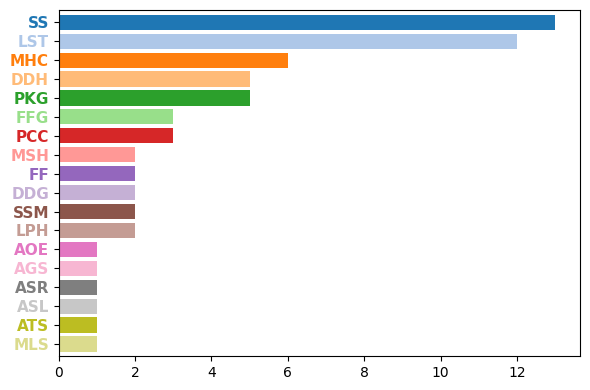

In [14]:
# 1) 데이터 준비 
shiptype_count_summary = ais.groupby('ShipType')['mmsi'].nunique().sort_values(ascending=False)

# 2) LLM 묘사를 위한 전처리
data_dict_shiptype = shiptype_count_summary.to_dict()
shiptype_data = json.dumps(data_dict_shiptype, ensure_ascii=False, indent=4)

#3) 데이터 Dashboard 시각화
plt.figure(figsize=(6, 4))
colors = plt.cm.tab20.colors

ax = shiptype_count_summary.plot(
    kind="barh",
    color=colors[:len(shiptype_count_summary)],
    width=0.8
) 

# Y 축 레이블 색상을 막대 색상과 일치시키기
tick_labels = ax.get_yticklabels()

for i, label in enumerate(tick_labels):
    label.set_color(colors[i])
    label.set_weight('bold')
    label.set_fontsize(11)

ax.invert_yaxis()
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [14]:
print(shiptype_data)

{
    "SS": 13,
    "LST": 12,
    "MHC": 6,
    "DDH": 5,
    "PKG": 5,
    "FFG": 3,
    "PCC": 3,
    "MSH": 2,
    "FF": 2,
    "DDG": 2,
    "SSM": 2,
    "LPH": 2,
    "AOE": 1,
    "AGS": 1,
    "ASR": 1,
    "ASL": 1,
    "ATS": 1,
    "MLS": 1
}


In [15]:
#####################################################
# 평균 Direction(향) 분석을 통한 지배적인 교통흐름 파악 #
#####################################################
def get_direction_analysis(df):
    # '이동' 중인 선박만 추출
    cruising_raw = df[df['status'] != '정박/대기'].copy()
    
    cruising = cruising_raw.groupby('mmsi').agg({
        'first_course': 'last',
        'avg_speed': 'mean'}).reset_index()
    
    if cruising.empty:
        return "현재 이동 중인 주요 선박 흐름 없음"

    # --- 1. 방향 그룹화 (Binning) ---
    # 0~360도를 8방위로 나누기 
    # 북쪽(North)은 337.5~22.5도 사이이므로, 계산 편의를 위해 범위 조절.
    bins = [-0.1, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360.1]
    labels = ['북', '북동', '동', '남동', '남', '남서', '서', '북서', '북'] 

    cruising['direction_group'] = pd.cut(cruising['first_course'], bins=bins, labels=labels, ordered=False)
    
    # --- 2. 통계 계산 ---
    # 각 방향별 선박 수 계산 및 0인 항목 제거
    flow_counts = cruising['direction_group'].value_counts()
    flow_counts = flow_counts[flow_counts > 0]

    unique_labels = []
    for l in labels:
        if l not in unique_labels:
            unique_labels.append(l)
    
    cruising['sin'] = np.sin(np.radians(cruising['first_course']))
    cruising['cos'] = np.cos(np.radians(cruising['first_course']))
    
    agg_flow = cruising.groupby('direction_group', observed=True).agg({
        'mmsi': 'count',
        'avg_speed': 'mean',
        'sin': 'mean',
        'cos': 'mean'
    })
    
    # 텍스 요약 생성
    flow_reports = []
    
    for direction in unique_labels: 
        if direction in agg_flow.index:
            data = agg_flow.loc[direction]
            count = int(data['mmsi'])
    
            if count == 0: continue
    
            curr_avg_speed = float(data['avg_speed'])
            vec_avg = float(np.degrees(np.arctan2(data['sin'], data['cos'])) % 360)
            
            flow_reports.append({
                "direction":f"{direction}진",
                "ship_count": count,
                "average_speed_knot": round(curr_avg_speed, 1),
                "vector_course_deg": round(vec_avg, 1)
            })
    return json.dumps(flow_reports, ensure_ascii=False, indent=4)


In [15]:
## 주요 향별 묘사를 위한 데이터 전처리##
# df_summarization 
def compress_ship_data_py(df):
    # 1. 데이터 타입 변환 및 정렬
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df['course'] = pd.to_numeric(df['course'])
    df['speed'] = pd.to_numeric(df['speed'])
    df = df.sort_values(['ShipName','timestamp'])

    # 2. 변화량 및 트리거 계산
    df['prev_lon'] = df.groupby('ShipName')['longitude'].shift(1).fillna(df['longitude'])
    df['prev_lat'] = df.groupby('ShipName')['latitude'].shift(1).fillna(df['latitude'])
    df['prev_course'] = df.groupby('ShipName')['course'].shift(1).fillna(df['course'])
    df['prev_speed'] = df.groupby('ShipName')['speed'].shift(1).fillna(df['speed'])

    # 1) 위치 변화 비교
    df['pos_change'] = np.where(
        (df['longitude'].round(3) != df['prev_lon'].round(3)) | 
        (df['latitude'].round(3) != df['prev_lat'].round(3)), 1, 0
    )

    # 2) 침로 변화 비교(180도 회전 보정 포함)
    df['course_diff_raw'] = df['course'] - df['prev_course']
    df['course_diff'] = np.where(df['course_diff_raw'] > 180, df['course_diff_raw'] - 360,
                        np.where(df['course_diff_raw'] < -180, df['course_diff_raw'] + 360,
                        df['course_diff_raw']))
    df['course_change'] = np.where((df['course_diff'].abs() >= 20) & (df['speed'] >= 1.0), 1, 0)

    # 3) 속도 변화
    df['speed_diff'] = df['speed'] - df['prev_speed']
    df['speed_change'] = np.where(df['speed_diff'].abs() >= 2, 1, 0)

    # 4) 이벤트 트리거 
    df['event_trigger'] = np.where((df['pos_change'] == 1) | (df['course_change'] == 1) | (df['speed_change'] == 1), 1, 0)
    df['group_id'] = df.groupby('ShipName')['event_trigger'].cumsum()

    # 5. 그룹별 요약
    df_summarized = df.groupby(['ShipName', 'group_id']).agg(
        mmsi = ('mmsi', 'first'),
        higher_types = ('higher_types', 'first'),
        radius = ('radius','first'),
        start_time = ('timestamp', 'min'),
        end_time = ('timestamp', 'max'),
        lon = ('longitude', 'first'),
        lat = ('latitude', 'first'),
        first_course = ('course', 'first'), 
        avg_speed = ('speed', 'mean'),
        turn_val = ('course_diff', 'first'),
        accel_val = ('speed_diff', 'first')
    ).reset_index()

    # 6. 그룹 간 속도 차이 및 최종 상태 판별
    df_summarized['prev_avg_speed'] = df_summarized.groupby('ShipName')['avg_speed'].shift(1).fillna(df_summarized['avg_speed'])
    df_summarized['group_speed_diff'] = df_summarized['avg_speed'] - df_summarized['prev_avg_speed']

    def determine_status(row):
        # 1순위: 정박/대기
        if row['avg_speed'] < 1.0:
            return "정박/대기"

        # 2순위: 운항 중 상세 상태 
        # 선회 판단
        turn_desc = ""
        if abs(row['turn_val']) >= 20 and row['avg_speed'] >= 1.0:
            direction = "우선회" if row['turn_val'] > 0 else "좌선회"
            turn_desc = f"{direction}({round(abs(row['turn_val']), 1)}°)"

        # 가감속 판단
        accel_desc = ""
        if row['group_speed_diff'] >= 2:
            accel_desc = "가속"
        elif row['group_speed_diff'] < -2:
            accel_desc = "감속"

        # 기본 이동 상태
        move_desc = "이동/통과" if row['avg_speed'] >= 5.0 else "저속 운항"

        # 정보 결합 (불필요한 공백 제거)
        status_parts = [turn_desc, accel_desc, move_desc]
        return " ".join([p for p in status_parts if p != ""]).strip()

    df_summarized['status'] = df_summarized.apply(determine_status, axis=1)

    # 불필요한 중간 계산 컬럼 삭제 후 반환
    return df_summarized.drop(columns=['prev_avg_speed'])

def compress_ship_data_py_further(df):
    df['prev_status'] = df.groupby('ShipName')['status'].shift(1).fillna(df['status'])
    # 1) status 변화 비교
    df['status_change'] = np.where(
        df['status'] != df['prev_status'], 1, 0
    )
    df['group_id'] = df.groupby('ShipName')['status_change'].cumsum()
    df_summarized = df.groupby(['ShipName', 'group_id']).agg(
        mmsi = ('mmsi', 'first'),
        higher_types = ('higher_types', 'first'),
        radius = ('radius','first'),
        start_time = ('start_time', 'min'),
        end_time = ('end_time', 'max'),
        lon = ('lon', 'first'),
        lat = ('lat', 'first'),
        first_course = ('first_course', 'first'), 
        avg_speed = ('avg_speed', 'mean'),
        turn_val = ('turn_val', 'first'),
        accel_val = ('accel_val', 'first'),
        status = ('status', 'first')
    ).reset_index()
    return df_summarized

In [24]:
ais

,ShipType,ShipName,mmsi,timestamp,course,speed,longitude,latitude,higher_types,radius,geometry
t,,,,,,,,,,,
2022-12-01 06:19:24+00:00,LST,LST-685 성인봉,215017000,2022-12-01 06:19:24 UTC,23.0,8.4,127.058950,32.044362,amphibious,9000,POINT (127.05895 32.04436)
2022-12-01 19:52:55+00:00,LST,LST-685 성인봉,215017000,2022-12-01 19:52:55 UTC,12.0,8.3,127.936867,33.761945,amphibious,9000,POINT (127.93687 33.76194)
2022-12-01 13:47:34+00:00,LST,LST-685 성인봉,215017000,2022-12-01 13:47:34 UTC,23.0,7.8,127.559078,33.001457,amphibious,9000,POINT (127.55908 33.00146)
2022-12-01 16:16:34+00:00,LST,LST-685 성인봉,215017000,2022-12-01 16:16:34 UTC,23.0,7.8,127.715658,33.301872,amphibious,9000,POINT (127.71566 33.30187)
2022-12-01 13:14:01+00:00,LST,LST-685 성인봉,215017000,2022-12-01 13:14:01 UTC,24.0,8.5,127.518982,32.927120,amphibious,9000,POINT (127.51898 32.92712)
...,...,...,...,...,...,...,...,...,...,...,...
2022-12-02 18:33:42+00:00,MHC,MHC-567 금화,667002156,2022-12-02 18:33:42 UTC,198.8,0.1,129.059542,35.103057,navalmine,7000,POINT (129.05954 35.10306)
2022-12-02 18:46:45+00:00,MHC,MHC-567 금화,667002156,2022-12-02 18:46:45 UTC,182.5,0.1,129.059548,35.103017,navalmine,7000,POINT (129.05955 35.10302)
2022-12-02 12:16:44+00:00,MHC,MHC-567 금화,667002156,2022-12-02 12:16:44 UTC,180.4,0.1,129.059523,35.103042,navalmine,7000,POINT (129.05952 35.10304)


In [16]:
status_sum = compress_ship_data_py(ais)
status_sum_further = compress_ship_data_py_further(status_sum)
print(f"status_sum has {status_sum.shape} & status_sum_further has {status_sum_further.shape}")

status_sum has (8530, 17) & status_sum_further has (1380, 14)


In [18]:
direction_flow_data = get_direction_analysis(status_sum_further)
print(direction_flow_data)

[
    {
        "direction": "북진",
        "ship_count": 3,
        "average_speed_knot": 10.3,
        "vector_course_deg": 5.8
    },
    {
        "direction": "북동진",
        "ship_count": 6,
        "average_speed_knot": 8.1,
        "vector_course_deg": 36.1
    },
    {
        "direction": "동진",
        "ship_count": 6,
        "average_speed_knot": 8.9,
        "vector_course_deg": 87.2
    },
    {
        "direction": "남동진",
        "ship_count": 6,
        "average_speed_knot": 10.9,
        "vector_course_deg": 145.8
    },
    {
        "direction": "남진",
        "ship_count": 5,
        "average_speed_knot": 8.4,
        "vector_course_deg": 176.4
    },
    {
        "direction": "남서진",
        "ship_count": 15,
        "average_speed_knot": 10.3,
        "vector_course_deg": 229.2
    },
    {
        "direction": "서진",
        "ship_count": 9,
        "average_speed_knot": 8.1,
        "vector_course_deg": 262.9
    },
    {
        "direction": "북서진",
        "ship_co

In [19]:
############################################################
### 주요 항만(부산, 울산, 광양, 목포)별 선박 입출항 현황 묘사 ###
############################################################

In [21]:
import holoviews as hv
import geopandas as gpd

# 주요 항만 데이터
ports_gdf = gpd.read_file('./data/major_ports.shp')
ports_gdf = ports_gdf.to_crs("EPSG:4326")

# 항만 입출항 판정 함수: 출항 선박은 반드시 해당 항구에서 출발하여, 항구 경계선 밖으로 나가야만 출항으로 판정
# 입항 선박은 항구 경계선 밖에서 시작하여 항구경계 안으로로 들어오 것만 인정
def is_leaving(traj, poly):
    #시작은 안에서, 끝은 밖에서
     return traj.get_start_location().intersects(poly) and not traj.get_end_location().intersects(poly)

def is_entering(traj, poly):
    #시작은 안에서, 끝은 밖에서
     return not traj.get_start_location().intersects(poly) and  traj.get_end_location().intersects(poly)

# 정박/대기 판정을 위한 데이터 전처리
stop_temp_df = compress_ship_data_py(ais)
stop_temp_df = compress_ship_data_py_further(stop_temp_df)

latest_indices = stop_temp_df.groupby('mmsi')['end_time'].idxmax()
latest_status_df = stop_temp_df.loc[latest_indices]

#축약된 데이터의 'end_time'이 검색시간 기준 1시간 이내인 행만 추출
end_time = pd.to_datetime(end_time, utc=True) #현재 필터링 기준 시간

latest_indices = stop_temp_df.groupby('mmsi')['end_time'].idxmax()
latest_status_df = stop_temp_df.loc[latest_indices].copy()
latest_status_df['end_time'] = pd.to_datetime(latest_status_df['end_time'], utc=True)

time_diff_threshold = end_time - latest_status_df['end_time']

stop_condition = (
    (time_diff_threshold >= pd.Timedelta(0)) &
    (time_diff_threshold <= pd.Timedelta(hours=1)) &
    (latest_status_df['status'].str.contains("정박/대기"))
)

anchored_ships = latest_status_df[stop_condition]

geometry = gpd.points_from_xy(anchored_ships['lon'], anchored_ships['lat'])
anchored_ships_gdf = gpd.GeoDataFrame(anchored_ships, geometry=geometry, crs="EPSG:4326")
anchored_ships_gdf

,ShipName,group_id,mmsi,higher_types,radius,start_time,end_time,lon,lat,first_course,avg_speed,turn_val,accel_val,status,geometry
848,LST-685 성인봉,9,215017000,amphibious,9000,2022-12-02 00:25:45+00:00,2022-12-02 22:59:14+00:00,128.365987,34.177740,76.0,0.157190,62.0,0.5,정박/대기,POINT (128.36599 34.17774)
1213,SS-065 박위,14,259005000,others,5000,2022-12-02 07:27:29+00:00,2022-12-02 22:56:13+00:00,127.965000,34.605000,253.0,0.044579,-19.4,-0.7,정박/대기,POINT (127.965 34.605)
1064,PKG-722 임병래,0,273331810,patrolship,10000,2022-12-01 00:00:06+00:00,2022-12-02 22:57:25+00:00,129.069807,35.095077,64.7,0.034705,0.0,0.0,정박/대기,POINT (129.06981 35.09508)
549,FF-959 부산,246,305062000,frigate,13000,2022-12-02 21:55:05+00:00,2022-12-02 22:58:25+00:00,129.556880,34.134203,112.1,0.435185,79.7,-0.7,정박/대기,POINT (129.55688 34.1342)
631,LPH-6111 독도,26,311039000,amphibious,9000,2022-12-02 06:35:01+00:00,2022-12-02 22:56:04+00:00,127.640978,34.884075,283.3,0.128046,42.9,-2.0,정박/대기,POINT (127.64098 34.88408)
604,FFG-818 대구,41,352002106,frigate,13000,2022-12-02 01:25:02+00:00,2022-12-02 22:57:56+00:00,129.081283,35.020233,260.0,0.117354,-17.0,-0.5,정박/대기,POINT (129.08128 35.02023)
927,MHC-565 김포,0,352403000,navalmine,7000,2022-12-01 00:04:18+00:00,2022-12-02 22:56:34+00:00,129.000825,35.052102,307.2,0.069641,0.0,0.0,정박/대기,POINT (129.00082 35.0521)
975,MSH- 해남,14,431006614,navalmine,7000,2022-12-02 03:55:09+00:00,2022-12-02 22:59:28+00:00,131.001172,33.778678,259.0,0.415011,2.7,-1.0,정박/대기,POINT (131.00117 33.77868)
960,MSH- 옹진,18,440467000,navalmine,7000,2022-12-01 23:00:09+00:00,2022-12-02 22:57:11+00:00,127.759267,34.895567,77.0,0.109818,-32.0,-0.6,정박/대기,POINT (127.75927 34.89557)
302,DDH-981 최영,16,466221000,destroyer,15000,2022-12-01 13:34:30+00:00,2022-12-02 22:58:30+00:00,127.892200,34.670233,286.0,0.113782,2.0,0.1,정박/대기,POINT (127.8922 34.67023)


In [23]:
geometry

<GeometryArray>
[<POINT (128.366 34.178)>, <POINT (127.965 34.605)>,  <POINT (129.07 35.095)>,
 <POINT (129.557 34.134)>, <POINT (127.641 34.884)>,  <POINT (129.081 35.02)>,
 <POINT (129.001 35.052)>, <POINT (131.001 33.779)>, <POINT (127.759 34.896)>,
  <POINT (127.892 34.67)>, <POINT (129.056 35.118)>, <POINT (128.343 34.203)>,
 <POINT (128.177 34.142)>, <POINT (127.725 34.909)>,  <POINT (129.06 35.103)>]
Length: 15, dtype: geometry

In [22]:
## 주요 항만별 입출항 현황 시각화 for Geospatial DASHBOARD ## 

# 1. 대상 항구 리스트
target_ports = ['BUSAN HANG', 'ULSAN HANG','GWANGYANG HANG, HADONG HANG', 'MOKPO HANG']
port_plots = []

for port_name in target_ports:
    # --- A. 해당 항구 폴리곤 및 영역(AOI) 추출 ---
    single_port_gdf = ports_gdf[ports_gdf['objnam'] == port_name]
    if single_port_gdf.empty: continue
    
    # 500m 버퍼 적용 (입출항 판정)
    port_projected = single_port_gdf.to_crs(epsg=5179)
    port_projected['geometry'] = port_projected.geometry.buffer(500)
    port_aoi = port_projected.to_crs(epsg=4326).geometry.iloc[0]

    # --- B. 해당 항구 범위 계산 (줌인용) ---
    bounds = single_port_gdf.geometry.total_bounds
    margin = 0.05  # 개별 항구 줌인이므로 마진을 작게 설정
    p_xlim = (bounds[0] - margin, bounds[2] + margin)
    p_ylim = (bounds[1] - margin, bounds[3] + margin)

    # --- C. 해당 항구 전용 데이터 필터링 ---
    # 출발/도착 항적 필터링
    p_departures = [t for t in trips if is_leaving(t, port_aoi)]
    p_arrivals = [t for t in trips if is_entering(t, port_aoi)]
    
    # 정박 선박 필터링 (해당 항구 폴리곤 안에 있는 것만)
    p_anchored = anchored_ships_gdf[anchored_ships_gdf.geometry.within(port_aoi)]

    # --- D. 개별 항구 레이어 생성 ---
    layers = []
    
    # 1. 배경 지도 및 항구 폴리곤 (가장 아래)
    layers.append(single_port_gdf.hvplot(
        title=f"{port_name} 현황", color='red', alpha=0.2, geo=True,
        tiles='OSM', xlim=p_xlim, ylim=p_ylim, 
        frame_width=350, frame_height=350 # 여러 개를 놓기 위해 크기 조절
    ))
    
    # 2. 출발 항적
    if p_departures:
        layers.append(mpd.TrajectoryCollection(p_departures).hvplot(color="blue", label="출발", line_width=2))
    
    # 3. 도착 항적
    if p_arrivals:
        layers.append(mpd.TrajectoryCollection(p_arrivals).hvplot(color="orange", label="도착", line_width=2))
    
    # 4. 정박 포인트
    if not p_anchored.empty:
        layers.append(p_anchored.hvplot.points(color='red', label="정박/대기", geo=True, size=5))

    # --- E. 항구별 오버레이 합체 후 리스트에 저장 ---
    port_plots.append(hv.Overlay(layers).opts(show_legend=(port_name == target_ports[0])))

# 2. 모든 항구 지도를 격자 형태로 배치
# .cols(2)는 한 줄에 2개씩 배치하겠다는 뜻입니다.
final_layout = hv.Layout(port_plots).cols(2)
final_plot = final_layout.opts(shared_axes=False) # 각 지도가 독립적인 범위를 갖도록 설정

final_plot

:Layout
   .Overlay.I   :Overlay
      .WMTS.I            :WMTS   [Longitude,Latitude]
      .Polygons.I        :Polygons   [Longitude,Latitude]
      .WMTS.II           :WMTS   [Longitude,Latitude]
      .Path.출발.I         :Path   [Longitude,Latitude]
      .Path.출발.II        :Path   [Longitude,Latitude]
      .Path.출발.III       :Path   [Longitude,Latitude]
      .Path.출발.IV        :Path   [Longitude,Latitude]
      .Path.출발.V         :Path   [Longitude,Latitude]
      .Points.출발.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.III     :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.IV      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.V       :Points   [Longitude,Latitude]   (triangle_angle)
      .WMTS.III          :WMTS   [Longitude,Latitude]
      .Path.도착.I         :Path   [Longitude,Latitude]
      .Path.도착.II        :Path   [Longitude,Latitude]
      .Points.도착.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.정박_over_대기 :Points   [Longitude,Latitude]
   .Overlay.II  :Overlay
      .WMTS.I       :WMTS   [Longitude,Latitude]
      .Polygons.I   :Polygons   [Longitude,Latitude]
      .WMTS.II      :WMTS   [Longitude,Latitude]
      .Path.출발.I    :Path   [Longitude,Latitude]
      .Path.출발.II   :Path   [Longitude,Latitude]
      .Points.출발.I  :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.II :Points   [Longitude,Latitude]   (triangle_angle)
      .WMTS.III     :WMTS   [Longitude,Latitude]
      .Path.도착.I    :Path   [Longitude,Latitude]
      .Path.도착.II   :Path   [Longitude,Latitude]
      .Points.도착.I  :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II :Points   [Longitude,Latitude]   (triangle_angle)
   .Overlay.III :Overlay
      .WMTS.I            :WMTS   [Longitude,Latitude]
      .Polygons.I        :Polygons   [Longitude,Latitude]
      .WMTS.II           :WMTS   [Longitude,Latitude]
      .Path.출발           :Path   [Longitude,Latitude]
      .Points.출발         :Points   [Longitude,Latitude]   (triangle_angle)
      .WMTS.III          :WMTS   [Longitude,Latitude]
      .Path.도착.I         :Path   [Longitude,Latitude]
      .Path.도착.II        :Path   [Longitude,Latitude]
      .Path.도착.III       :Path   [Longitude,Latitude]
      .Path.도착.IV        :Path   [Longitude,Latitude]
      .Points.도착.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.III     :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.IV      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.정박_over_대기 :Points   [Longitude,Latitude]
   .Overlay.IV  :Overlay
      .WMTS.I       :WMTS   [Longitude,Latitude]
      .Polygons.I   :Polygons   [Longitude,Latitude]
      .WMTS.II      :WMTS   [Longitude,Latitude]
      .Path.출발.I    :Path   [Longitude,Latitude]
      .Path.출발.II   :Path   [Longitude,Latitude]
      .Points.출발.I  :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.II :Points   [Longitude,Latitude]   (triangle_angle)
      .WMTS.III     :WMTS   [Longitude,Latitude]
      .Path.도착.I    :Path   [Longitude,Latitude]
      .Path.도착.II   :Path   [Longitude,Latitude]
      .Points.도착.I  :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II :Points   [Longitude,Latitude]   (triangle_angle)

In [22]:
#####################################
### 데이터 검증을 위한 temp 리포트 생성


# 분석할 항구 리스트 (시각화와 동일하게 설정)
target_ports = ['BUSAN HANG', 'ULSAN HANG', 'GWANGYANG HANG, HADONG HANG', 'MOKPO HANG']

print("="*60)
print(f"항만별 선박 입출항 및 정박 현황 리포트 ({start_time} ~ {end_time})")
print("="*60)

for port_name in target_ports:
    # 1. 해당 항구 폴리곤 추출 및 버퍼 설정
    single_port_gdf = ports_gdf[ports_gdf['objnam'] == port_name]
    if single_port_gdf.empty:
        continue
    
    # 입출항 판정용 버퍼(500m)
    port_projected = single_port_gdf.to_crs(epsg=5179)
    port_projected['geometry'] = port_projected.geometry.buffer(500)
    port_aoi = port_projected.to_crs(epsg=4326).geometry.iloc[0]

    # 2. 해당 항구 데이터 필터링
    # 출발/도착 항적
    p_departures = [t for t in trips if is_leaving(t, port_aoi)]
    p_arrivals = [t for t in trips if is_entering(t, port_aoi)]
    
    # 정박 선박 (전체 정박 데이터 중 해당 항구 폴리곤 내 위치한 것)
    p_anchored = anchored_ships_gdf[anchored_ships_gdf.geometry.within(port_aoi)]

    # 3. 리포트 출력
    print(f"\n[ {port_name} 분석 결과 ]")
    print("-" * 30)
    
    # A. 정박 현황
    print(f"▶ 정박/대기 중인 선박: 총 {len(p_anchored)}척")
    if not p_anchored.empty:
        for _, row in p_anchored.iterrows():
            print(f"   - {row['ShipName']} ({row['mmsi']}): {row['start_time'].strftime('%Y-%m-%d %H:%M:%S')}부터 정박 중")
    else:
        print("   - 현재 정박 중인 선박 없음")

    # B. 출발 현황
    print(f"▶ 출발/기동 선박: 총 {len(p_departures)}척")
    for traj in p_departures:
        st = traj.get_start_time()
        name = traj.df['ShipName'].iloc[0]
        stype = traj.df['ShipType'].iloc[0]
        mmsi = traj.df['mmsi'].iloc[0].split('_')[0]
        print(f"   - {stype} '{name}({mmsi})': {st} 에 출발")

    # C. 도착 현황
    print(f"▶ 도착/진입 선박: 총 {len(p_arrivals)}척")
    for traj in p_arrivals:
        et = traj.get_end_time()
        name = traj.df['ShipName'].iloc[0]
        stype = traj.df['ShipType'].iloc[0]
        mmsi = traj.df['mmsi'].iloc[0].split('_')[0]
        print(f"   - {stype} '{name}({mmsi})': {et} 에 도착")
    
    print("-" * 30)

print("\n리포트 생성이 완료되었습니다.")

항만별 선박 입출항 및 정박 현황 리포트 (2022-12-01 00:00:00 ~ 2022-12-02 23:00:00+00:00)

[ BUSAN HANG 분석 결과 ]
------------------------------
▶ 정박/대기 중인 선박: 총 4척
   - PKG-722 임병래 (273331810): 2022-12-01 00:00:06부터 정박 중
   - MHC-565 김포 (352403000): 2022-12-01 00:04:18부터 정박 중
   - MHC-563 고령 (477024700): 2022-12-01 00:01:07부터 정박 중
   - MHC-567 금화 (667002156): 2022-12-01 00:01:24부터 정박 중
▶ 출발/기동 선박: 총 5척
   - ATS 'ATS- 평택(215080000)': 2022-12-01 12:12:05 에 출발
   - LST 'LST-681 고준봉(215183000)': 2022-12-01 12:02:02 에 출발
   - LST 'LST-672 덕봉(244693000)': 2022-12-01 08:45:40 에 출발
   - PKG 'PKG-718 현시학(563709000)': 2022-12-01 23:10:38 에 출발
   - LST 'LST-673 비봉(636015481)': 2022-12-01 09:55:04 에 출발
▶ 도착/진입 선박: 총 2척
   - ATS 'ATS- 평택(215080000)': 2022-12-01 08:48:05 에 도착
   - SS 'SS-061 장보고(371002000)': 2022-12-02 12:00:56 에 도착
------------------------------

[ ULSAN HANG 분석 결과 ]
------------------------------
▶ 정박/대기 중인 선박: 총 0척
   - 현재 정박 중인 선박 없음
▶ 출발/기동 선박: 총 2척
   - SS 'SS-062 이천(440562000)': 2022-12-01 00:

In [20]:
########################################
### LLM전달을 위한 분석결과 데이터 json출력

import json
from datetime import datetime

# 결과를 담을 메인 딕셔너리
report_data = {
    "report_info": {
        "analysis_period": {
            "start": str(start_time),
            "end": str(end_time)
        },
        "generated_at": datetime.now().isoformat(),
        "target_ports": target_ports
    },
    "ports_analysis": []
}

for port_name in target_ports:
    # 1. 데이터 필터링 (기존 로직 동일)
    single_port_gdf = ports_gdf[ports_gdf['objnam'] == port_name]
    if single_port_gdf.empty: continue
    
    port_projected = single_port_gdf.to_crs(epsg=5179)
    port_projected['geometry'] = port_projected.geometry.buffer(500)
    port_aoi = port_projected.to_crs(epsg=4326).geometry.iloc[0]

    p_departures = [t for t in trips if is_leaving(t, port_aoi)]
    p_arrivals = [t for t in trips if is_entering(t, port_aoi)]
    p_anchored = anchored_ships_gdf[anchored_ships_gdf.geometry.within(port_aoi)]

    # 2. 항구별 JSON 구조 생성
    port_entry = {
        "port_name": port_name,
        "summary": {
            "anchored_count": len(p_anchored),
            "departure_count": len(p_departures),
            "arrival_count": len(p_arrivals)
        },
        "details": {
            "anchored_ships": [
                {
                    "name": row['ShipName'],
                    "mmsi": int(row['mmsi']),
                    "anchored_since": str(row['start_time'].strftime('%Y-%m-%d %H:%M:%S'))
                } for _, row in p_anchored.iterrows()
            ],
            "departures": [
                {
                    "name": t.df['ShipName'].iloc[0],
                    "type": t.df['ShipType'].iloc[0],
                    "mmsi": int(str(t.id).split('_')[0]),
                    "event_time": str(t.get_start_time())
                } for t in p_departures
            ],
            "arrivals": [
                {
                    "name": t.df['ShipName'].iloc[0],
                    "type": t.df['ShipType'].iloc[0],
                    "mmsi": int(str(t.id).split('_')[0]),
                    "event_time": str(t.get_end_time())
                } for t in p_arrivals
            ]
        }
    }
    report_data["ports_analysis"].append(port_entry)

# 3. JSON 출력 및 저장
major_ports_sum = json.dumps(report_data, indent=4, ensure_ascii=False)

print(major_ports_sum) # 화면 출력

# 필요한 경우 파일로 저장
# with open('port_analysis_report.json', 'w', encoding='utf-8') as f:
#     f.write(json_output)

{
    "report_info": {
        "analysis_period": {
            "start": "2022-12-01 00:00:00",
            "end": "2022-12-02 23:00:00+00:00"
        },
        "generated_at": "2026-04-16T14:42:49.826981",
        "target_ports": [
            "BUSAN HANG",
            "ULSAN HANG",
            "GWANGYANG HANG, HADONG HANG",
            "MOKPO HANG"
        ]
    },
    "ports_analysis": [
        {
            "port_name": "BUSAN HANG",
            "summary": {
                "anchored_count": 4,
                "departure_count": 5,
                "arrival_count": 2
            },
            "details": {
                "anchored_ships": [
                    {
                        "name": "PKG-722 임병래",
                        "mmsi": 273331810,
                        "anchored_since": "2022-12-01 00:00:06"
                    },
                    {
                        "name": "MHC-565 김포",
                        "mmsi": 352403000,
                        "anchored_s

In [24]:
######################
### 상태별 선박 묘사 ###
######################

# 현재시점 기준 이동/통과, 저속 운항, 정박/대기 함정 추출 

def ship_status_extraction(df, end_time): #df = 추출된 선박
    df = compress_ship_data_py(df)
    df = compress_ship_data_py_further(df)
    end_time = pd.to_datetime(end_time, utc=True) #현재 필터링 기준 시간
    df['end_time'] = pd.to_datetime(df['end_time'], utc=True)
    df = df.sort_values(['ShipName','mmsi'])
    df = df.groupby('ShipName').tail(1)

    #이동 통과 filtering
    moving_condition = (
        ((end_time - df['end_time']) <= pd.Timedelta(hours=1)) &
        (df['status'].str.contains("이동/통과"))
    )

    #정박/대기  filtering
    stop_condition = (
        ((end_time - df['end_time']) <= pd.Timedelta(hours=1)) &
        (df['status'].str.contains("정박/대기"))
    )

    #저속운항 filtering 
    slow_moving_condition = (
        ((end_time - df['end_time']) <= pd.Timedelta(hours=1)) &
        (df['status'].str.contains("저속 운항"))
    )

    #이동/통과 중인 선박 리스트 추출 및 json변환
    moving_df = df[moving_condition]
    moving_ships = moving_df[['ShipName','mmsi','status']].drop_duplicates().to_dict(orient='records')
    moving_ships_json = json.dumps(moving_ships, ensure_ascii=False, indent=4)

    #정박/대기 중인 선박 리스트 추출 및 json변환
    stop_df = df[stop_condition]
    stop_ships = stop_df[['ShipName','mmsi','status']].drop_duplicates().to_dict(orient='records')
    stop_ships_json = json.dumps(stop_ships, ensure_ascii=False, indent=4)

    #정박/대기 중인 선박 리스트 추출 및 json변환
    slow_df = df[slow_moving_condition]
    slow_ships = slow_df[['ShipName','mmsi','status']].drop_duplicates().to_dict(orient='records')
    slow_ships_json = json.dumps(slow_ships, ensure_ascii=False, indent=4)
    
    return moving_ships_json, stop_ships_json, slow_ships_json

    #현재 이동 중인 선박 리스트 추출


moving_result, stopping_result, slow_result = ship_status_extraction(ais, end_time)

print(moving_result)
print("="*55)
print(stopping_result)
print("="*55)
print(slow_result)


[
    {
        "ShipName": "AGS- 신천지",
        "mmsi": 352001086,
        "status": "우선회(49.0°) 이동/통과"
    },
    {
        "ShipName": "AOE-59 화천",
        "mmsi": 431016257,
        "status": "이동/통과"
    },
    {
        "ShipName": "DDH-972 을지문덕",
        "mmsi": 538002403,
        "status": "이동/통과"
    },
    {
        "ShipName": "DDH-973 양만춘",
        "mmsi": 538008114,
        "status": "우선회(70.0°) 이동/통과"
    },
    {
        "ShipName": "FF-961 청주",
        "mmsi": 538009442,
        "status": "이동/통과"
    },
    {
        "ShipName": "FFG-813 전북",
        "mmsi": 636022499,
        "status": "이동/통과"
    },
    {
        "ShipName": "LST-683 향로봉",
        "mmsi": 563161700,
        "status": "이동/통과"
    },
    {
        "ShipName": "MHC-562 강진",
        "mmsi": 538005766,
        "status": "이동/통과"
    },
    {
        "ShipName": "MLS-560 원산함",
        "mmsi": 636021418,
        "status": "이동/통과"
    },
    {
        "ShipName": "PCC-781 남원",
        "mmsi": 319409000,
        

In [25]:
##############################
## 특이 기동 선박 분석 및 추출 ##
##############################

### 선회 또는 속도변화가 빈번했던 선박 리스트 추출

def unusual_ships_extraction(df):
    df = status_sum_further
    df = compress_ship_data_py_further(df)

    # 1) 분석 키워드 정의
    turn_keywords = ['우선회', '좌선회']
    speed_keywords = ['가속', '감속']

    # 2) 각 행별로 특이 기동여부 체크
    df['is_turning'] = df['status'].str.contains('|'.join(turn_keywords))
    df['is_speed_changing'] = df['status'].str.contains('|'.join(speed_keywords))

    # 3) ShipName별로 그룹화하여 특이 기동 횟수 집계
    behavior_summary = df.groupby('ShipName').agg(
        turn_count = ('is_turning', 'sum'),
        speed_change_count = ('is_speed_changing', 'sum'),
        total_records = ('status', 'count'),
        status_list=('status', lambda x: list(x.unique()))
    ).reset_index()

    unusual_ships_df = behavior_summary[
        (behavior_summary['turn_count'] >= 4) | 
        (behavior_summary['speed_change_count'] >= 4)
        ].sort_values(by='turn_count', ascending=False)

    unusual_ships_json = unusual_ships_df[['ShipName','turn_count','speed_change_count', 'status_list']].to_dict(orient='records')
    unusual_final_report_json = json.dumps(unusual_ships_json, ensure_ascii=False, indent=4)
    
    return unusual_final_report_json


unusual_behavior = unusual_ships_extraction(ais)
print(unusual_behavior)

[
    {
        "ShipName": "FF-959 부산",
        "turn_count": 81,
        "speed_change_count": 11,
        "status_list": [
            "이동/통과",
            "좌선회(30.2°) 이동/통과",
            "가속 이동/통과",
            "감속 이동/통과",
            "좌선회(23.4°) 이동/통과",
            "좌선회(99.8°) 가속 이동/통과",
            "좌선회(23.7°) 이동/통과",
            "좌선회(24.7°) 이동/통과",
            "감속 저속 운항",
            "우선회(27.5°) 저속 운항",
            "좌선회(33.0°) 저속 운항",
            "정박/대기",
            "우선회(86.2°) 저속 운항",
            "좌선회(39.4°) 저속 운항",
            "우선회(173.4°) 저속 운항",
            "좌선회(162.6°) 저속 운항",
            "저속 운항",
            "좌선회(55.1°) 저속 운항",
            "좌선회(149.4°) 저속 운항",
            "좌선회(32.2°) 저속 운항",
            "좌선회(176.9°) 저속 운항",
            "좌선회(133.9°) 저속 운항",
            "좌선회(175.1°) 저속 운항",
            "좌선회(129.1°) 저속 운항",
            "우선회(20.2°) 저속 운항",
            "우선회(58.1°) 저속 운항",
            "우선회(40.5°) 저속 운항",
            "우선회(75.5°) 저속 운항",
            "우선회(64.6°) 저

In [26]:
############################
### LLM을 활용한 답변 통합 ###
############################

#####################################
### "LOCAL" VLLM MODEL Initiation ###
#####################################
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

#vllm starter 
vllm = ChatOpenAI(
    api_key = "ai",
    base_url = "http://192.168.0.110:8000/v1", # for A6000
    # base_url = "http://192.168.0.108:8000/v1", # for A5000
    model = "openai/gpt-oss-20b",
    # model = "unsloth/Meta-Llama-3.1-70B-Instruct-bnb-4bit"
    # model = "unsloth/gemma-3-27b-it-bnb-4bit",
    # model="meta-llama/Llama-3.1-8B-Instruct",
    # model="mistralai/Mistral-7B-Instruct-v0.3",
    # model="Qwen/Qwen2-7B-Instruct",
    # model="unsloth/Mistral-Small-24B-Instruct-2501-bnb-4bit",
    # model = "unsloth/Qwen3-14B-bnb-4bit",
    # model = "unsloth/gemma-3-12b-it-bnb-4bit",
    # model = "unsloth/gemma-2-9b-it-bnb-4bit",
    max_tokens = 6000,
    temperature = 0.2
)

In [27]:
# 전체패턴 요약을 위한 프롬프트 템플릿 최적화를 위한 수정
def prompt_template_trajs_overall(start_time, end_time, time_diff,
                                  clusters_data, speed_data,
                                  direction_flow_data,
                                  trajs_flow_data, shiptype_data, major_ports_sum, 
                                  moving_result, stopping_result, slow_result, 
                                  unusual_behavior):
    return f"""
    # Role
    당신은 대한민국 해양수산부 소속의 '해상교통관제(VTS) 데이터 분석 전문가' 입니다.
    제공된 통계 데이터를 바탕으로 해상 교통의 [전체 흐름 - 항만 현황 - 특이 기동]을 체계적으로 분석하여 보고서를 작성하세요.  

    #Input Data (Summarized Statistics)
    1. [분석 대상 시간]:
    - 시작 시점: {start_time}
    - 종료 시점: {end_time}
    - (약 {time_diff} 동안의 데이터 집계 결과)
    2. [구역별 밀집 현황]: 
    {clusters_data}
    3. [구역별 선박 이동 속도 현황]:
    {speed_data}
    4. [주요 교통 흐름 요약]:
    {direction_flow_data}
    5. [구역 간 주요 항로(OD Flow) 현황]: 
    {trajs_flow_data}
    6. [선박 유형별 통계]:
    {shiptype_data}
    7. [주요 항만별 선박 입출항 현황]:
    {major_ports_sum}
    8. [선박 상태별 현황 요약]:
    - 순항 중인 선박 리스트: {moving_result}  
    - 정박/대기 중인 선박 리스트: {stopping_result}
    - 저속 운항 중인 선박 리스트: {slow_result}
 
    9. [특이 기동 선박]:
    {unusual_behavior}
    
    # Context & Rules (필독)
    - **[데이터 근거]**: 모든 분석은 수치에만 근거하며, 상상이나 추측은 엄격히 금지합니다.  
    - **[전문성]**: 병목 구간, 간선 항로, 트래픽 밀도 등 필요에 따라 전문 용어를 적절히 배치하십시오.  

    # Mission: 리포트 구성 가이드라인

    1. **[분석 대상 시간]**: 1번 데이터를 자연스러운 문장으로 묘사.  
    2. **[구역별 밀집 현황]**: 
        - 2번 'clusters_data'에서 'total_stay_index'가 높을수록 해당 구역에 더 많은 항적이 밀집되어 있음을 의미합니다.  
        - 이를 기준으로 상위 3개 핵심 해역을 선정하여 테이블로 만들어주고, 테이블 아래 해당 지역의 항적 밀집 패턴을 간단하게 요약하세요.  
    3. **[구역별 선박 이동 속도 현황]**: 
        - 2번 'speed_data'에서 'mean'은 해상구역별 평균속도를 의미합니다.
        - 2번 'speed_data'를 활용하여 각 구역별 선박의 평균 속도 분포를 비교하고, 대한민국 남해안 해역에서 연안과 외해, 그리고 주요 항만 주변 간의 전반적인 핵심 패턴을 설명하세요.   
    4. **[주요 교통 흐름 요약]**: 
        -4번 'direction_flow_data'데이터를 바탕으로 현재 가장 지배적인 이동 방향을 식별하세요. 
        -해당 흐름의 규모 및 이동 속도의 특성을 간략하게 요약하여 기술하세요.  
    5. **[구역 간 주요 항로(OD Flow) 현황]**: 
        - 5번 'trajs_flow_data'에서 'weight'값이 높을수록 해당 경로(origin_zone -> dest_zone)는 주 간선 항로(Main Route)임을 의미합니다.
        - 'trajs_flow_data'를 활용하여 'weight' 기준 상위 5개 항로를 분석하여 대한민국 남해안의 주요 항로 패턴이 어떻게 형성되어 있는지 설명하세요. 
    6. **[선박 유형별 통계]**: 
        - 6번 '선박 유형별 통계'는 반드시 Markdown테이블 형식을 사용하십시오.
        - 6번 'shiptype_data'를 활용하여 선박 유형별 카운트 테이블에 대해 가장 높은 비중을 차지하는 상위 3개 함종이 무엇인지 간단하게 설명하세요. 
    7. **[주요 항만별 선박 입출항 현황]**: 
        - 7번 'major_ports_sum'데이터를 활용하여 주요 항만별 선박 입출항 현황을 다음 예시와 같이 기술해주세요. 
            예시 1:
            ▶ 정박/대기 중인 선박: 총 4척
           - PKG-722 임병래 (273331810): 2022-12-01 00:00:06부터 정박 중
           - MHC-565 김포 (352403000): 2022-12-01 00:04:18부터 정박 중
           - MHC-563 고령 (477024700): 2022-12-01 00:01:07부터 정박 중
           - MHC-567 금화 (667002156): 2022-12-01 00:01:24부터 정박 중
            ▶ 출발/기동 선박: 총 5척
           - ATS 'ATS- 평택': 2022-12-01 12:06:01 에 출발
           - LST 'LST-681 고준봉': 2022-12-01 12:22:20 에 출발
           - LST 'LST-672 덕봉': 2022-12-01 08:20:09 에 출발
           - PKG 'PKG-718 현시학': 2022-12-01 23:00:47 에 출발
           - LST 'LST-673 비봉': 2022-12-01 09:58:31 에 출발
            ▶ 도착/진입 선박: 총 2척
           - ATS 'ATS- 평택': 2022-12-01 08:54:02 에 도착
           - SS 'SS-061 장보고': 2022-12-02 11:55:04 에 도착
            
            위 예시의 "부터 정박 중", " 에 출발", " 에 도착"이라는 조사와 서술어를 하나도 빠짐없이 포함해서 답변해줘.  
    8. **[선박 상태별 현황 요약]**: 
        - 아래 예제와 같이 각 카테고리 별로 'ShipName', 'mmsi' 리스트만 정리해줘. 테이블로 전시하지 마. 
            ▶ 순항 중인 선박 리스트
            - AST-688 일천봉(256011000)
            - DDG-992 율곡이이(431400833)
            ▶ 정박 중인 선박 리스트
            - AST-688 일천봉(256011000)
            - DDG-992 율곡이이(431400833)
            ▶ 저속 운항 중인 선박 리스트
            - AST-688 일천봉(256011000)
            - DDG-992 율곡이이(431400833)

    9. **[주요 선박 특이 기동 상세 분석]**: 
        - 제공된 9번 데이터 'unusual_bahavior'를 바탕으로 답변해줘.
        - 특히 좌선회 및 우선회등 선회가 빈번하거나 가속 감속 등 속도 변화가 잦은 선박을 우선적으로 기술해줘. 
        - 다음 제공된 예시와 같이 작성해줘. 
            ▶ 특이 기동 식별 보고
           - [선박명]: 'turn_count'회의 변침과 'speed_change_count'회의 속도 변화 포착.
           - 분석 내용: 'status_list'의 상태를 인용하여 기동의 특이점 간략하게 요약.

    10. **[종합 결론]**:  
        - 현재 데이터상에서 나타나는 가장 두드러진 해상 교통 특징 및 관제 주의사항 간략하게 요약하여 기술하세요. 

    # Tone & Manner
    - 전문가용 관제 보고서 스타일 (명조체 중심의 정중하고 명확한 문체)
    - 수치와 제공된 데이터 기반 팩트 위주의 서술
    """

In [28]:
# Local LLM call 함수
def execute_llm_prompt(model, prompt_input):
    # LangChain's chat models take a list of message objects
    prompt_response = model.invoke(
        [
            HumanMessage(content=prompt_input)
        ],
        temperature = 0.1
    )
    # the following if statement is for preprocessing answers from QWEN since it contains <think> section by defulat. 
    if "<think>" in prompt_response.content:
        prompt_response = removing_think_from_qwen(prompt_response)
        return prompt_response

    else:
        return prompt_response.content

In [29]:
############################
##LLM을 통한 통합 답변 생성 ##

major_trajs_desc = prompt_template_trajs_overall(start_time, end_time, time_diff, 
                                                 clusters_data, speed_data,
                                                 direction_flow_data,
                                                 trajs_flow_data, shiptype_data, 
                                                 major_ports_sum,
                                                 moving_result, stopping_result, slow_result, 
                                                 unusual_behavior)

answer_major_trajs_desc = execute_llm_prompt(vllm, major_trajs_desc)

print(answer_major_trajs_desc)

**해상교통관제(VTS) 데이터 분석 보고서**  
*분석 기간: 2022‑12‑01 00:00:00 ~ 2022‑12‑02 23:00:00+00:00*  

---

### 1. 분석 대상 시간  
2022년 12월 1일 00시 00분 00초부터 2022년 12월 2일 23시 00분 00초까지 총 1일 23시간 동안의 해상 교통 데이터를 집계하였다.  

---

### 2. 구역별 밀집 현황  
| 순위 | 구역명 | 총 체류 지수 (total_stay_index) |
|------|--------|--------------------------------|
| 1 | 부산‑가덕 해역 | 100 |
| 2 | 여수‑통영 외해 | 99 |
| 3 | 시모노세키‑기타큐슈 해역 | 75 |

**항적 밀집 패턴 요약**  
- 부산‑가덕 해역과 여수‑통영 외해는 연안에 인접해 있어 항적이 가장 집중되어 있다.  
- 시모노세키‑기타큐슈 해역은 일본 동해안에 위치해 있으며, 국내 해역보다 상대적으로 항적이 적지만 여전히 높은 밀집도를 보인다.  

---

### 3. 구역별 선박 이동 속도 현황  
| 구역명 | 평균 속도 (mean, knot) | 최대 속도 (max, knot) | 관측 횟수 (count) |
|--------|------------------------|-----------------------|-------------------|
| 부산‑대마도 입구 해역 | 12.06 | 19.2 | 1 269 |
| 거제‑가덕 외해 | 6.06 | 19.4 | 1 592 |
| 부산‑가덕 해역 | 1.13 | 102.3 | 9 468 |
| 원거리 국제공해 | 10.09 | 19.0 | 1 069 |
| 시모노세키‑기타큐슈 해역 | 4.39 | 17.3 | 2 860 |
| 기타 | … | … | … |

**핵심 패턴**  
- **연안·항만 주변**(부산‑가덕, 거제‑가덕 외해)에서는 평균 속도가 1–6 knot으로 낮아, 정박·대기·저속 운항이 